In [2]:
import numpy as onp
import jax
from jax import Array
import jax.numpy as jnp
import jax.random as jrnd
import sympy as sp

from jax.scipy.special import xlogy

jax.config.update('jax_enable_x64', 'false')

### MPL Config

In [3]:
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.axes import Axes

mpl.rcParams.update({
  "font.size": 16,
  "axes.titlesize": 20,
  "axes.labelsize": 16,
  "xtick.labelsize": 9,
  "ytick.labelsize": 9,
  "figure.dpi": 150,
  "savefig.dpi": 300,
  "pdf.fonttype": 42,
  "ps.fonttype": 42,
  "mathtext.fontset": "dejavusans",
  "text.usetex": True,
  "font.family": "Helvetica",
})


### Funcs

In [4]:
def matrix_powers(G, N):
  def step(Gk, _):
    return Gk @ G, Gk

  _, Gs = jax.lax.scan(
    step,
    init=jnp.eye(G.shape[0], dtype=G.dtype),
    xs=None,
    length=N,
  )
  return Gs  # [I, G, G^2, ..., G^(N-1)]

# ---- entropy and KL divergence use convention that 0 log 0 = 0
def S(p):
  return - jnp.sum(jnp.where(p==0, 0.0, p * jnp.log(p)))

def KL(p, q):
  return jnp.sum(jnp.where(p==0, 0.0, xlogy(p,p) - xlogy(p,q)))


def get_q_star(p: Array, G: Array, n_steps: Array):
  Gs = matrix_powers(G, N)
  traj = jax.vmap(lambda G_i: G_i @ p)(Gs)
  return jnp.mean(traj, axis=0)

def bound(p: Array, G: Array, n_steps: int):
  Gs = matrix_powers(G, n_steps)
  Gn = G @ Gs[-1]
  traj = jax.vmap(lambda G_i: G_i @ p)(Gs)
  q_star = jnp.mean(traj, axis=0)
  gen_landauer =  S(p) - S(Gn @ p)
  return -gen_landauer + n_steps * (S(q_star) - S(G @ q_star)), gen_landauer


def bound2(p: Array, G: Array, n_steps: int):
  def step(carry, _):
    p_i, agg = carry
    return (G @ p_i, agg + p_i), None

  d = p.shape[0]
  out, _ = jax.lax.scan(
    step, 
    init=(p, jnp.zeros((d,))), 
    xs=None, 
    length=n_steps
  )
  # p_n = G^np
  p_n, traj_f = out
  q_star = traj_f / n_steps
  gen_landauer =  S(p) - S(p_n)
  return -gen_landauer + n_steps * (S(q_star) - S(G @ q_star)), gen_landauer



def bound3(p: Array, G: Array, n_steps: int):
  def step(carry, _):
    Gi, agg = carry
    return (G @ Gi, agg + Gi @ p), None
  
  d = p.shape[0]
  out, _ = jax.lax.scan(step, init=(jnp.eye(d, d), jnp.zeros((d,))), xs=None, length=n_steps)
  Gn, traj_f = out
  q_star = traj_f / n_steps
  gen_landauer =  S(p) - S(Gn @ p)
  return -gen_landauer + n_steps * (S(q_star) - S(G @ q_star)), gen_landauer

  

def mmc(
  q: Array, 
  G: Array,
  p0: Array,
  n_steps: int,
):
  Gq = G @ q
  # Gs = matrix_powers(G, n_steps)
  def mmc1(p_i, _):
    p_next = G @ p_i
    cost_i = (
      KL(p_i, q) - KL(p_next, Gq)
    )
    return p_next, cost_i
  
  _, costs = jax.lax.scan(mmc1, init=p0, xs=None, length = n_steps)
  return jnp.sum(costs)



In [ ]:
from jax._src.basearray import Array


from scipy.optimize import minimize

def q_from_theta(theta: jax.Array) -> jax.Array:
  # theta has length 2; fix the third logit to zero
  logits = jnp.concatenate([
      theta,
      jnp.zeros(1, dtype=theta.dtype),
  ])

  return jax.nn.softmax(logits)


def make_objective(n_steps):


  def objective(theta: jax.Array) -> jax.Array:
    q = q_from_theta(theta)
    return mmc(q, G, p0, n_steps)

  # Compile the objective and its exact JAX gradient
  value_and_grad = jax.jit(jax.value_and_grad(objective))

  def scipy_objective(theta_np):
    value, gradient = value_and_grad(jnp.asarray(theta_np))

    return (
        float(value),
        onp.asarray(gradient, dtype=onp.float64),
    )

  return scipy_objective


### 3-state Toy Example 1

In [ ]:
d = 3
φ = 0.01
G = jnp.array([
  [1 - φ, φ, 0],
  [0, 1 - φ, φ],
  [φ, 0, 1 - φ]
])
# p0 = jnp.ones((d,))/d
p0 = jrnd.uniform(key, (d,))
p0 = p0 / jnp.sum(p0)

### 3-state Toy Example 2

In [ ]:
SIMPLEX_VERTICES = onp.array([
  [0.0, 0.0],
  [1.0, 0.0],
  [0.5, onp.sqrt(3.0) / 2.0],
])

def simplex_to_cartesian(points):
  return onp.asarray(points) @ SIMPLEX_VERTICES

def sample_simplex(levels=45):
  points = []
  for i in range(levels + 1):
    for j in range(levels + 1 - i):
      k = levels - i - j
      points.append((i / levels, j / levels, k / levels))
  return jnp.array(points, dtype=jnp.float32)

def regularize_simplex(points, eps=1e-3):
  # Keep KL terms finite near the simplex boundary without changing the plot mesh.
  points = jnp.clip(points, eps, None)
  return points / jnp.sum(points, axis=-1, keepdims=True)

def format_prob(point):
  return "(" + ", ".join(f"{x:.2f}" for x in onp.asarray(point)) + ")"

def normalize_simplex_point(point):
  point = onp.asarray(point)
  return point / point.sum()

def draw_simplex_frame(ax: Axes, color="0.25", lw=1.0):
  verts = SIMPLEX_VERTICES[[0, 1, 2, 0]]
  ax.plot(verts[:, 0], verts[:, 1], color=color, lw=lw, zorder=2)

def add_corner_labels(ax: Axes, fontsize=9, color="0.2"):
  ax.text(SIMPLEX_VERTICES[0,0] - 0.03, SIMPLEX_VERTICES[0,1] - 0.00,
          r"$(1,0,0)$", ha="right", va="top", fontsize=fontsize, color=color)
  ax.text(SIMPLEX_VERTICES[1,0] + 0.03, SIMPLEX_VERTICES[1,1] - 0.00,
          r"$(0,1,0)$", ha="left", va="top", fontsize=fontsize, color=color)
  ax.text(SIMPLEX_VERTICES[2,0], SIMPLEX_VERTICES[2,1] + 0.03,
          r"$(0,0,1)$", ha="center", va="bottom", fontsize=fontsize, color=color)



In [ ]:
# ---- data
n_values = (1, 10, 100, 500)

grid = sample_simplex(levels=60)
grid_eval = regularize_simplex(grid)
grid_xy = simplex_to_cartesian(grid)
triang = mtri.Triangulation(grid_xy[:, 0], grid_xy[:, 1])

mmc_by_n = {}
q_star_by_n = {}
for n in n_values:
  evaluator = jax.jit(jax.vmap(lambda q: mmc(q, G, p0, n)))
  mmc_by_n[n] = onp.asarray(evaluator(grid_eval))
  q_star_by_n[n] = onp.asarray(get_q_star(p0, G, n))

traj = onp.array([get_q_star(p0, G, n) for n in range(1, n_values[-1] + 1)])
traj_xy = simplex_to_cartesian(traj)

vmin=min(values.min() for values in mmc_by_n.values())
vmax=max(values.max() for values in mmc_by_n.values())


print(min(values.min() for values in mmc_by_n.values()))
norm = mcolors.SymLogNorm(linthresh=1e-2, vmin=vmin, vmax=vmax)

In [ ]:
# ---- figure
fig = plt.figure(figsize=(8.5,7.3), constrained_layout=True, dpi=300)
gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.06])

axs = [
  fig.add_subplot(gs[0, 0]),
  fig.add_subplot(gs[0, 1]),
  fig.add_subplot(gs[1, 0]),
  fig.add_subplot(gs[1, 1]),
]
cax = fig.add_subplot(gs[:, 2])

# fig, axes = plt.subplots(len(n_values) // 2, 2, figsize=(12, len(n_values) // 2 * 6), constrained_layout=True)
# axs: list[Axes] = onp.array(axes).flatten().tolist()

panel_labels = ["(a)", "(b)", "(c)", "(d)"]


mappable = None
for i, (ax, n) in enumerate(zip(axs, n_values)):
  values = mmc_by_n[n]

  q_star = q_star_by_n[n]
  q_star_simplex = normalize_simplex_point(q_star)
  q_star_xy = simplex_to_cartesian(q_star_simplex)

  mappable = ax.tripcolor(
    triang,
    mmc_by_n[n],
    shading="gouraud",
    cmap="viridis",
    norm=norm,
    rasterized=True,
  )

  draw_simplex_frame(ax, color="0.20", lw=1.0)
  # add_corner_labels(ax, fontsize=8.5, color="0.25")

  # trajectory up to N
  ax.plot(
    traj_xy[:n, 0],
    traj_xy[:n, 1],
    color="white",
    lw=1.2,
    alpha=0.85,
    zorder=3,
  )

  ax.scatter(
    q_star_xy[0], q_star_xy[1],
    color="white",
    s=28,
    zorder=4
  )

  ax.annotate(
    rf"$q^* = {format_prob(q_star)}$",
    xy=q_star_xy + onp.array([0.02, -0.1]),
    xytext=(6, 6),
    textcoords="offset points",
    fontsize=16,
    color="k",
    bbox=dict(
      boxstyle="round,pad=0.2",
      fc="white",
      ec="0.7",
      lw=0.6,
      alpha=0.7,
    ),
    zorder=5,
  )

  ax.text(
      0.02, 0.97, panel_labels[i],
      transform=ax.transAxes,
      ha="left", va="top",
      fontsize=16, color="0.15"
  )

  ax.set_title(rf"$N = {n}$", pad=4)
  ax.set(
    aspect='equal',
    xlim=(-0.01, 1.01), 
    ylim=(-0.01, SIMPLEX_VERTICES[2, 1] + 0.01),
  )
  ax.axis("off")

cb = fig.colorbar(mappable, cax=cax)
cb.set_label(r"$\mathcal{M}_N(q;G,p_0)$", rotation=90, labelpad=10) # fontsize=14
cb.ax.tick_params(labelsize=16)

fig.savefig('simplex_heatmap.pdf')
plt.show()

### 4-State DFA

In [5]:
d = 4
N = 10
key = jrnd.PRNGKey(0)

def make_dfa_G(pa):
  pb = 1 - pa
  G = jnp.array([
    [pa, pb, 0.0, 0.0], 
    [pa, 0.0, pb, 0.0], 
    [pa, 0.0, 0.0, pb], 
    [0.0, 0.0, 0.0, pa + pb],
  ]).T
  return G

G = make_dfa_G(0.99)
# initial state delta on r_0
p0 = jnp.array([1.0, 0.0, 0.0, 0.0])

for n in (1, 2, 10, 100, 1000000):
  print(get_q_star(p0, G, n))



[9.90997936e-01 8.91998525e-03 7.92999016e-05 2.77899901e-06]
[9.90997936e-01 8.91998525e-03 7.92999016e-05 2.77899901e-06]
[9.90997936e-01 8.91998525e-03 7.92999016e-05 2.77899901e-06]
[9.90997936e-01 8.91998525e-03 7.92999016e-05 2.77899901e-06]
[9.90997936e-01 8.91998525e-03 7.92999016e-05 2.77899901e-06]


In [6]:
vals = []
for pa in onp.linspace(0.01, 0.99, 100):
  G = make_dfa_G(pa)
  mmcs = []
  for n in range(1, 101):
    mmc_anal, gen_landauer = bound2(p0, G, n)
    mmcs.append((n, mmc_anal))

  pts = onp.array(mmcs)
  vals.append((pa, pts))

vals_list = vals.tolist() if isinstance(vals, onp.ndarray) else vals
pas = onp.array([float(pa) for pa, _ in vals_list])
ns = onp.array([int(n) for n, _ in vals_list[0][1]])


Z = onp.stack(
  [onp.array([float(mmc) for _, mmc in pts]) for _, pts in vals_list],
  axis=1,  # rows = N, cols = pa
)

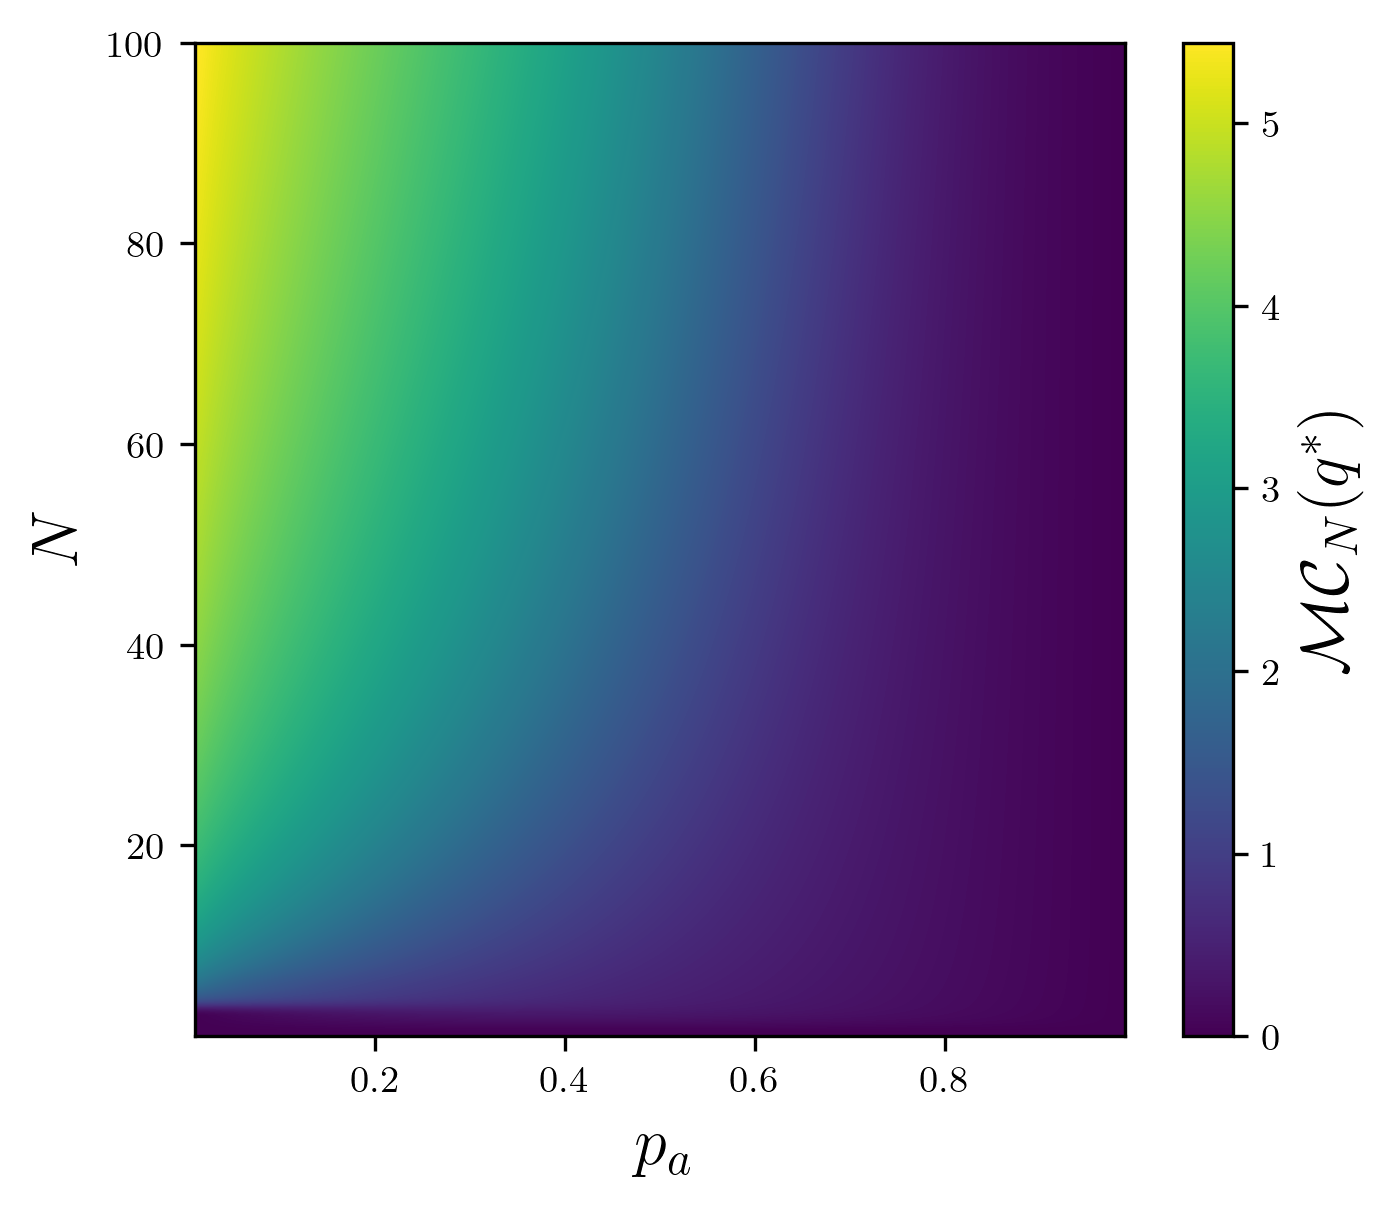

In [15]:

pa_step = pas[1] - pas[0] if len(pas) > 1 else 1.0
n_step = ns[1] - ns[0] if len(ns) > 1 else 1.0

fig, ax = plt.subplots(figsize=(5, 4.3), dpi=300)
im = ax.imshow(
  X=Z,
  origin="lower",
  aspect="auto",
  cmap="viridis",
  extent=[
    pas.min(), #- pa_step / 2,
    pas.max(), #+ pa_step / 2,
    ns.min(), #- n_step / 2,
    ns.max(), #+ n_step / 2,
  ],
  rasterized=True,
  interpolation="quadric",
)

ax.set(xlabel=r"$p_a$", ylabel=r"$N$")
# title="MMC Bound Heatmap"
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$\mathcal{MC}_N(q^*)$")
fig.savefig('DFA_heatmap.pdf')
plt.show()

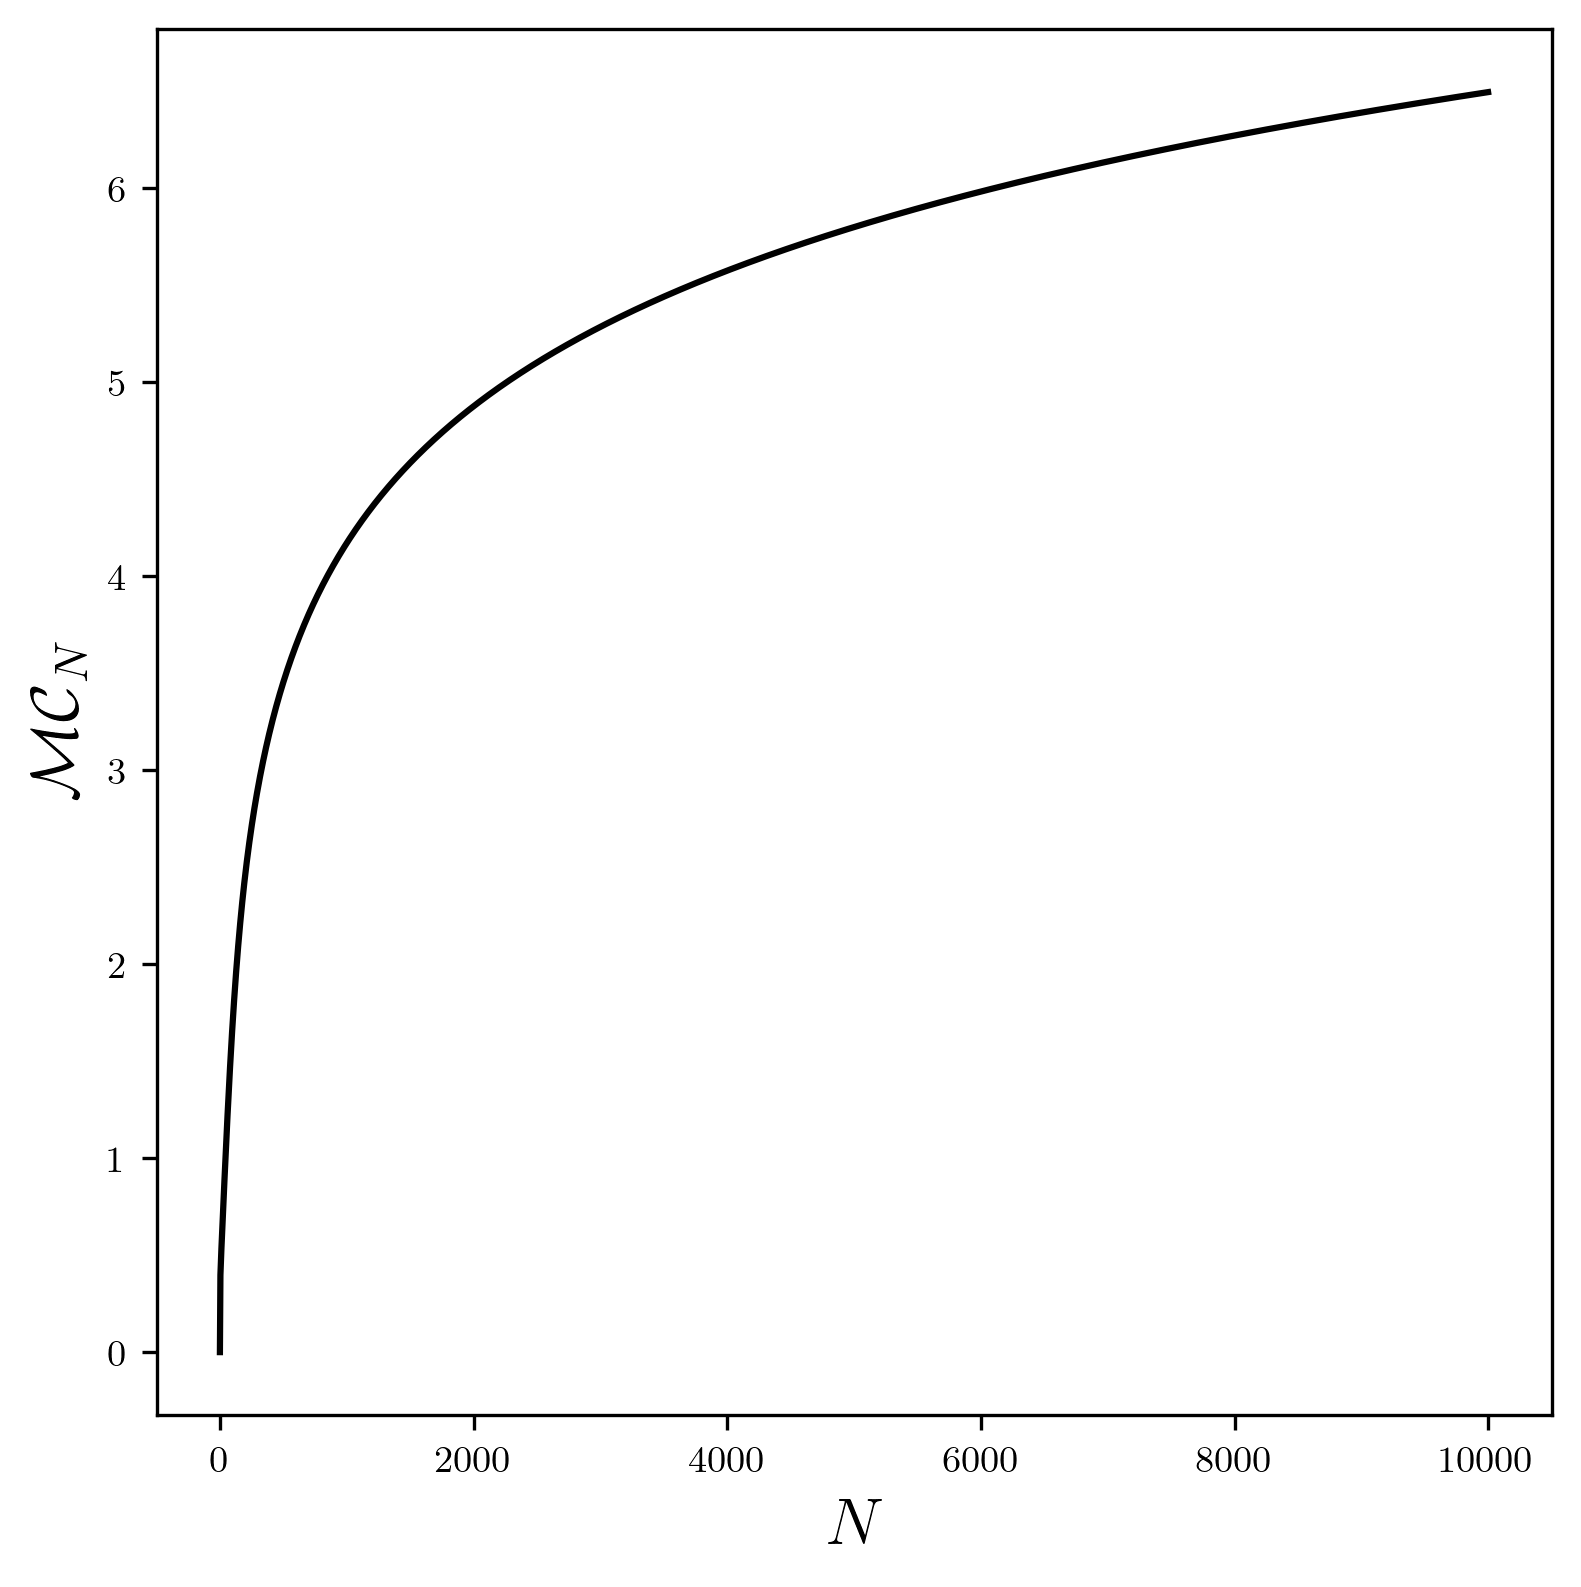

In [9]:
pa = 0.6
G = make_dfa_G(pa)
mmcs = []
for n in range(1, 10000, 4):
  mmc_anal, gen_landauer = bound2(p0, G, n)
  mmcs.append((n, mmc_anal, gen_landauer))

pts = onp.array(mmcs)

fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
ax.plot(pts[:, 0], pts[:, 1], c='k')
ax.set(xlabel=r"$N$", ylabel=r"$\mathcal{MC}_N$")
fig.savefig('DFA_lineplot.pdf')
plt.show()

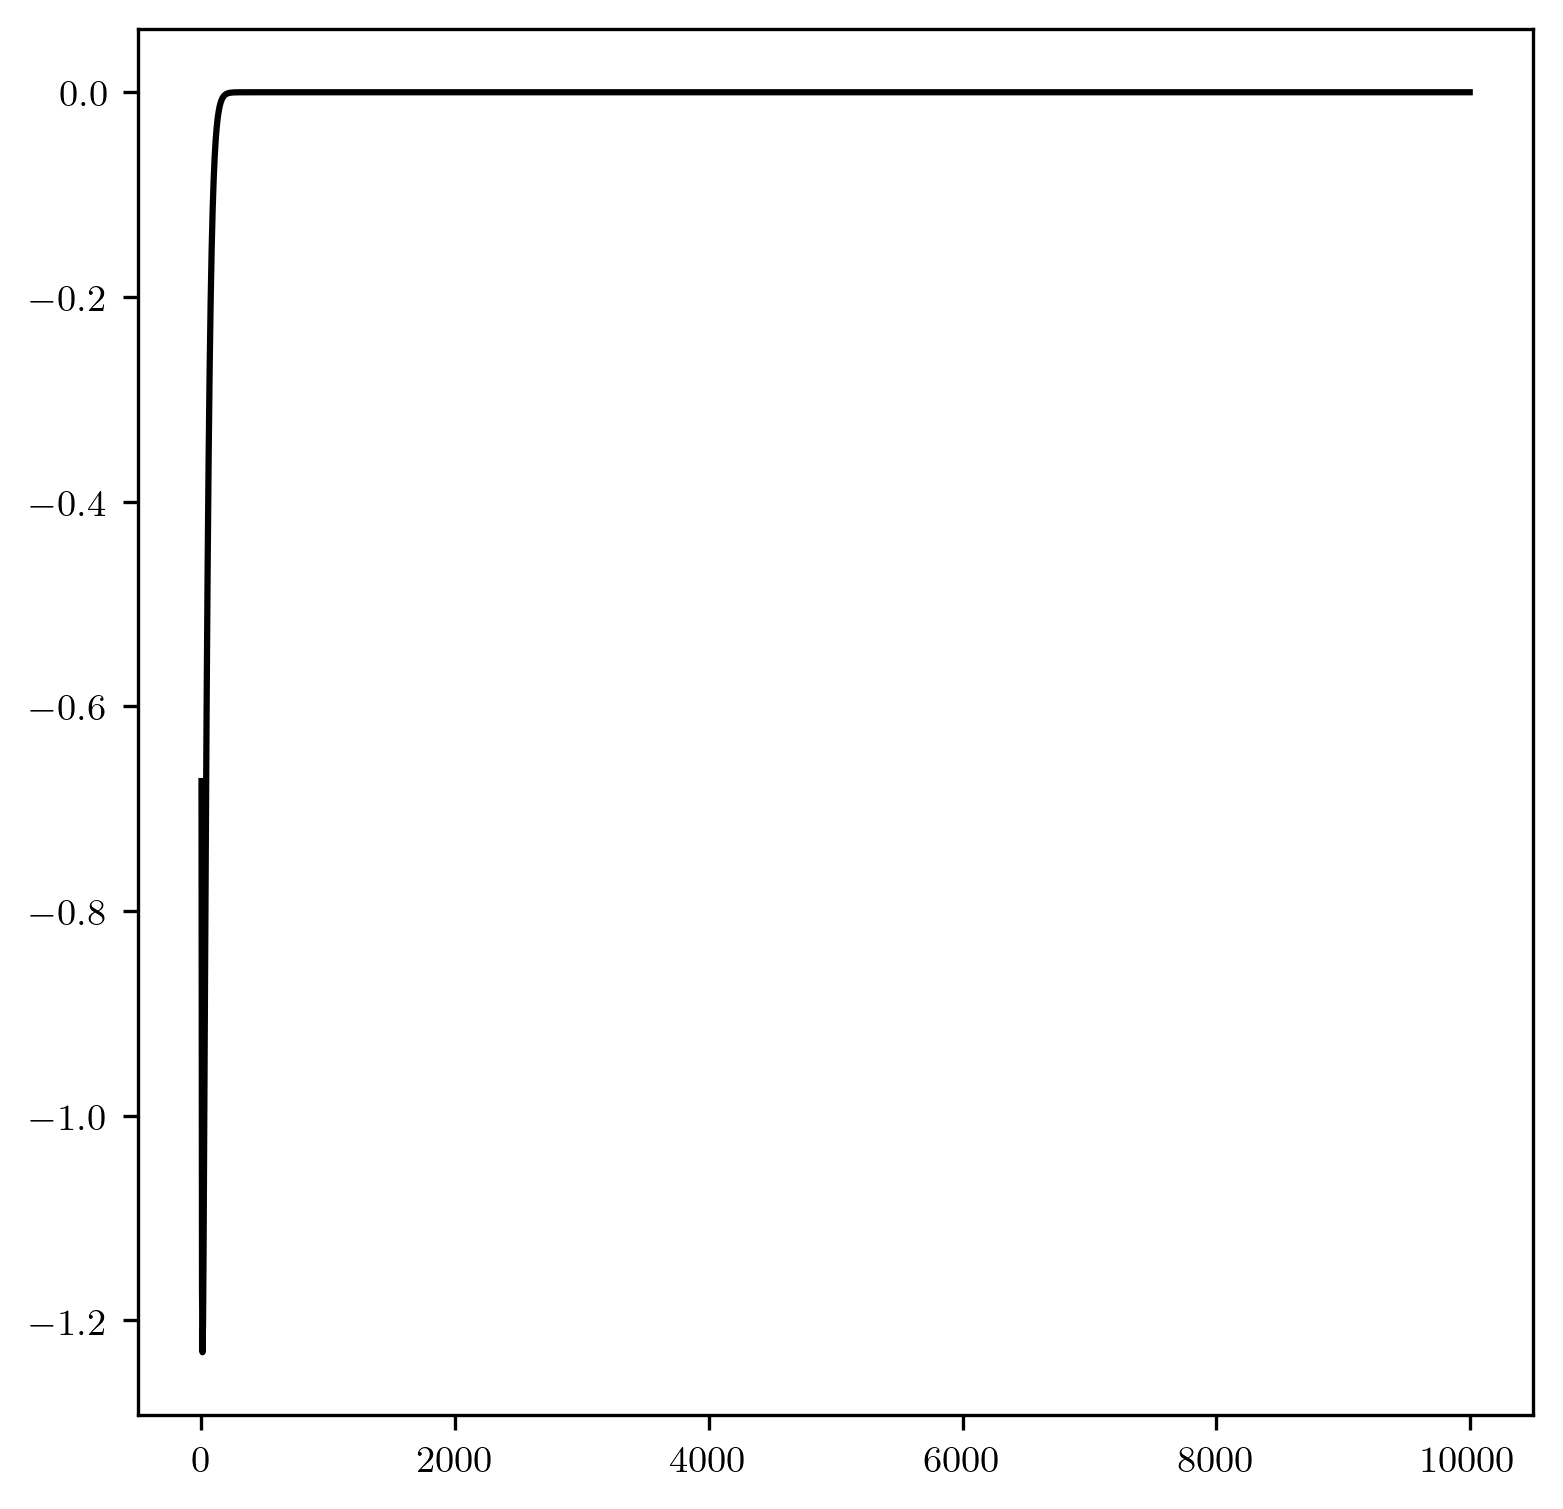

In [11]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
ax.plot(pts[:, 0], pts[:, 2], c='k')

In [10]:
mmcs = []
for n in range(4, 1000, 8):
  mmc_anal, gen_landauer = bound(p0, G, n)
  mmcs.append((n, mmc_anal))

pts = onp.array(mmcs)

import matplotlib.pyplot as plt
plt.plot(pts[:, 0], pts[:, 1])
plt.show()
plt.semilogx(pts[:, 0], pts[:, 1])
plt.show()

KeyboardInterrupt: 

In [ ]:



result = minimize(
  scipy_objective,
  x0=onp.zeros(d-1),
  jac=True,
  method="BFGS",
  options={
      "gtol": 1e-10,
      "maxiter": 1000,
  },
)

theta_opt = jnp.asarray(result.x)
q_opt = q_from_theta(theta_opt)
mmc_opt: Array = mmc(q_opt, G, p0, N)



print("Success:", result.success)
print("q*:", q_opt)
print("Minimum MMC:", mmc_opt)
print(onp.sum(q_opt))
mmc_anal, gen_landauer = bound(p0, G, N)
print(mmc_anal, gen_landauer)
# print(get_q_star(p0, G, N) - q_opt)


In [ ]:

def σ2(q, p):
  _is = jnp.arange(N)
  Gs = jax.vmap(pow_G)(_is)
  def mmc1(c, x):
    p_cur, agg = c
    p_next = G @ p_cur
    return (p_next, agg + KL(p_cur, q) - KL(p_next, G * q)), None
  mmc = jax.lax.scan(mmc1, init=(0, jnp.eye(3)), xs=Gs)
  return mmc[0]


In [ ]:
# ---- old code from the other DFC paper

# local dynamics (λi, ri−1) → (λi, ri) = (λi, ρ (λi, ri−1)). 
G = jnp.array([
  [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0],
  [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0],
  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0],
  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0],
  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0],
]).T
print(G)

p0 = jnp.array([0.5, 0., 0., 0., 0.5, 0.0, 0.0, 0.0])

def refresh_matrix(pa=0.5):
  pb = 1.0 - pa

  C = jnp.array([
    [pa, pa],
    [pb, pb],
  ])

  return jnp.kron(C, jnp.eye(4))

R = refresh_matrix(0.5)
print(R)
K = R @ G